In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans , DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import joblib


In [4]:
n = 200
data = {
        "CustomerId" : np.arange(1,n+1),
        "Gender" : np.random.choice(["Male", "Female"] , n),
        "Age" : np.random.randint(18,70,n),
        "Annual Income(k$)" : np.random.randint(15,150,n),
        "Spending Score (1-100)" : np.random.randint(1,100,n)
}

In [16]:
df = pd.DataFrame(data)
print(df.columns)

Index(['CustomerId', 'Gender', 'Age', 'Annual Income(k$)',
       'Spending Score (1-100)'],
      dtype='object')


D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl

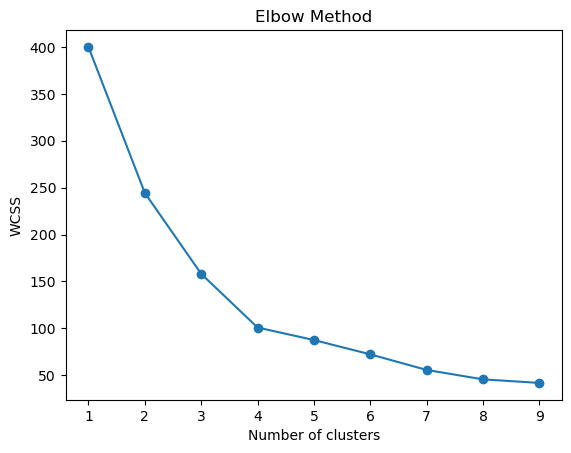

In [21]:
df= df.drop('CustomerId',axis=1)
df["Gender"] = df["Gender"].map({"Male" :0 , "Female" :1 })
X = df[["Annual Income(k$)" , "Spending Score (1-100)"]]
scaler = StandardScaler()
X_Scaled = scaler.fit_transform(X)

wcss = []
for k in range(1,10):
    kmeans = KMeans(n_clusters=k , random_state = 42)
    kmeans.fit(X_Scaled)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1,10) , wcss, marker = 'o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()
           


D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


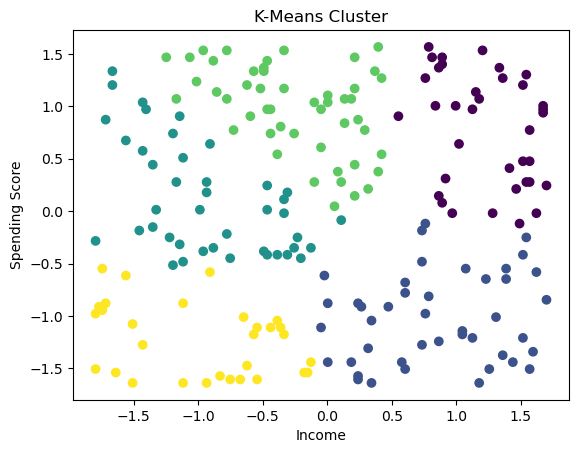

In [23]:
kmeans = KMeans(n_clusters=5, random_state=42)
label_kmeans = kmeans.fit_predict(X_Scaled)

plt.figure()
plt.scatter(X_Scaled[:,0] , X_Scaled[:,1] , c = label_kmeans)
plt.title("K-Means Cluster")
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.show()


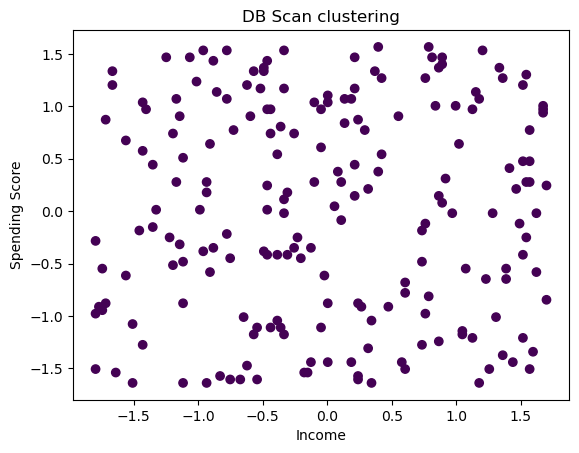

In [25]:
dbscan = DBSCAN(eps=0.5 , min_samples= 5)
labels_dbscan = dbscan.fit_predict(X_Scaled)
plt.figure()
plt.scatter(X_Scaled[:,0] , X_Scaled[:,1] , c=labels_dbscan)
plt.title("DB Scan clustering")
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.show()

In [27]:
print(silhouette_score(X_Scaled , label_kmeans))
print(silhouette_score(X_Scaled , labels_dbscan))

      

0.36161127136741783


ValueError: Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)

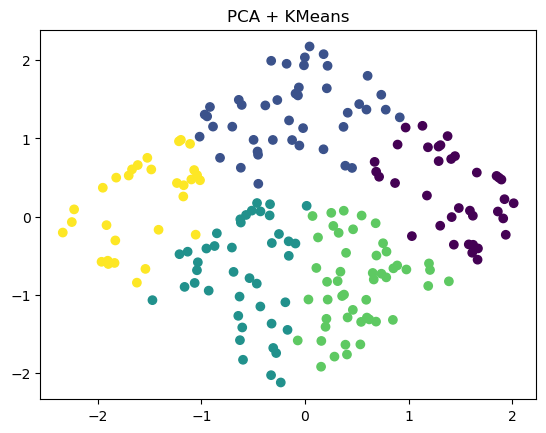

In [29]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_Scaled)

plt.figure()
plt.scatter(X_pca[:,0],X_pca[:,1] , c=label_kmeans)
plt.title("PCA + KMeans")
plt.show()
